# RAG 청크 품질 검증 노트북

**목적**:청크 품질을 수치로 측정한다.

**검증 항목**
1. 환경 설정 및 RAG 파이프라인 연결
2. Similarity Score 분포 분석
3. 청크 내용 품질 측정 (길이·한국어 비율·노이즈)
4. match_count 민감도 분석 (k=3 vs 5 vs 10)
5. 질문 유형별 검색 정밀도 육안 검토
6. RAGAS 정량 평가 (Faithfulness / Context Precision / Answer Relevancy)
7. 종합 요약 및 개선 방향

---
## 1. 환경 설정

In [10]:
import sys
import os

# 프로젝트 루트를 Python 경로에 추가
CURRENT_DIR = os.path.abspath('')
PROJECT_ROOT = os.path.dirname(CURRENT_DIR)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import warnings, re, platform
warnings.filterwarnings('ignore')

# 한국어 폰트
if platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
    try:
        fe = fm.FontEntry(fname=font_path, name='NanumGothic')
        fm.fontManager.ttflist.insert(0, fe)
        plt.rcParams['font.family'] = 'NanumGothic'
    except:
        pass
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

# 프로젝트 모듈 임포트
from services.db_service import search_rag_documents

print('환경 설정 완료')
print(f'프로젝트 경로: {PROJECT_ROOT}')

환경 설정 완료
프로젝트 경로: c:\Users\vacke\Desktop\hub\project\seoul_energy_rag


---
## 2. Similarity Score 분포 분석

> **핵심 질문**: 반환되는 청크의 유사도 점수가 실제로 높은가?
>
> - 0.85 이상: 매우 관련 있는 청크
> - 0.70 ~ 0.85: 관련 있을 수 있음
> - 0.70 미만: 노이즈일 가능성

In [11]:
# 질문 유형별 테스트 쿼리셋
TEST_QUERIES = {
    '자치구 특성':  [
        '강남구 에너지 소비 특성',
        '동작구 가정용 전력 비율',
        '종로구 서비스업 전력 현황',
        '도봉구 주거 에너지 특성',
        '금천구 산업용 전력 비율',
    ],
    '군집 분석': [
        '서울시 에너지 소비 군집 특성',
        '주거 밀집 군집 특성',
        '도심 상업 군집 에너지',
        '광역 거점 자치구 에너지 패턴',
        '군집별 가스 보급률 차이',
    ],
    '트렌드 변화': [
        '서울시 전력 소비 연도별 변화',
        '가정용 전력 비율 추세',
        '인구 감소와 에너지 소비 관계',
        '코로나 이후 에너지 소비 변화',
        '산업용 전력 비율 감소 원인',
    ],
    '비교 분석': [
        '강남구 동작구 비교',
        '중구 도봉구 에너지 구조 차이',
        '상업 중심지와 주거 지역 전력 비율',
        '서초구 강북구 차이점',
        '소득 수준과 에너지 소비 패턴',
    ],
}

print(f'총 테스트 쿼리: {sum(len(v) for v in TEST_QUERIES.values())}개')

총 테스트 쿼리: 20개


In [12]:
# 전체 쿼리에 대해 RAG 검색 실행 (match_count=5)
all_results = []

for category, queries in TEST_QUERIES.items():
    for q in queries:
        docs = search_rag_documents(q, match_count=10)  # 10개 가져와서 분포 확인
        for rank, doc in enumerate(docs, 1):
            all_results.append({
                'category':   category,
                'query':      q,
                'rank':       rank,
                'chunk_id':   doc.get('chunk_id'),
                'section':    doc.get('section'),
                'similarity': doc.get('similarity', 0),
                'content':    doc.get('content', ''),
                'content_len': len(doc.get('content', '')),
            })

df_rag = pd.DataFrame(all_results)
print(f'수집 완료: {len(df_rag)}행 ({df_rag['query'].nunique()}개 쿼리 * 10개 청크)')
print(f'\nSimilarity 기술통계:')
print(df_rag.similarity.describe().round(4))

[DEBUG] RAG Query: 강남구 에너지 소비 특성
[DEBUG] RPC Returned Row Count : 10 (threshold=0.7)
[DEBUG] RAG Query: 동작구 가정용 전력 비율
[DEBUG] RPC Returned Row Count : 7 (threshold=0.7)
[DEBUG] RAG Query: 종로구 서비스업 전력 현황
[DEBUG] RPC Returned Row Count : 9 (threshold=0.7)
[DEBUG] RAG Query: 도봉구 주거 에너지 특성
[DEBUG] RPC Returned Row Count : 10 (threshold=0.7)
[DEBUG] RAG Query: 금천구 산업용 전력 비율
[DEBUG] RPC Returned Row Count : 2 (threshold=0.7)
[DEBUG] RAG Query: 서울시 에너지 소비 군집 특성
[DEBUG] RPC Returned Row Count : 10 (threshold=0.7)
[DEBUG] RAG Query: 주거 밀집 군집 특성
[DEBUG] RPC Returned Row Count : 5 (threshold=0.7)
[DEBUG] RAG Query: 도심 상업 군집 에너지
[DEBUG] RPC Returned Row Count : 10 (threshold=0.7)
[DEBUG] RAG Query: 광역 거점 자치구 에너지 패턴
[DEBUG] RPC Returned Row Count : 10 (threshold=0.7)
[DEBUG] RAG Query: 군집별 가스 보급률 차이
[DEBUG] RPC Returned Row Count : 5 (threshold=0.7)
[DEBUG] RAG Query: 서울시 전력 소비 연도별 변화
[DEBUG] RPC Returned Row Count : 10 (threshold=0.7)
[DEBUG] RAG Query: 가정용 전력 비율 추세
[DEBUG] RPC Returned Row Count 

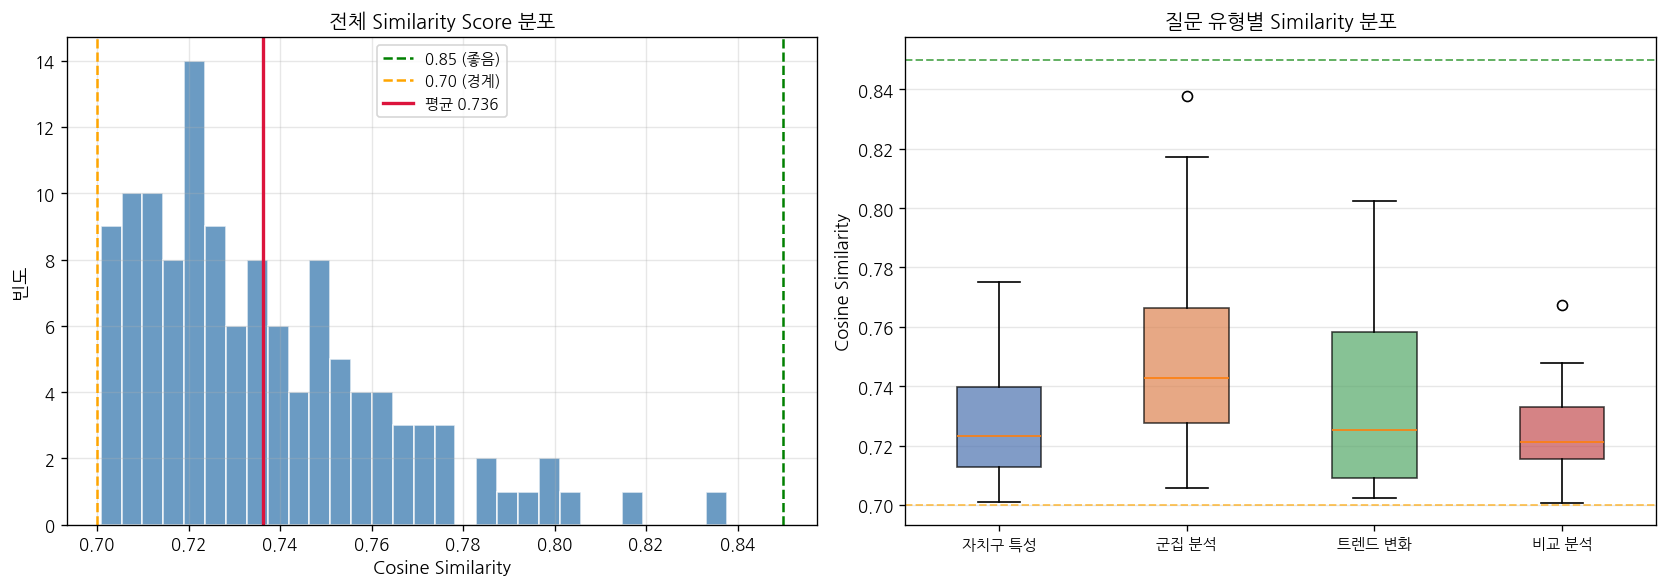

similarity >= 0.85: 0.0%
0.70 ~ 0.85:        100.0%
similarity < 0.70:  0.0%  ← 노이즈 의심 구간


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── 전체 similarity 분포 ──
ax = axes[0]
ax.hist(df_rag.similarity, bins=30, color='steelblue', alpha=0.8, edgecolor='white')
ax.axvline(0.85, color='green',  linestyle='--', linewidth=1.5, label='0.85 (좋음)')
ax.axvline(0.70, color='orange', linestyle='--', linewidth=1.5, label='0.70 (경계)')
ax.axvline(df_rag.similarity.mean(), color='crimson', linestyle='-',
           linewidth=2, label=f'평균 {df_rag.similarity.mean():.3f}')
ax.set_xlabel('Cosine Similarity', fontsize=11)
ax.set_ylabel('빈도', fontsize=11)
ax.set_title('전체 Similarity Score 분포', fontsize=12)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# ── 쿼리 유형별 similarity 박스플롯 ──
ax2 = axes[1]
categories = list(TEST_QUERIES.keys())
data_by_cat = [df_rag[df_rag.category==c].similarity.values for c in categories]
bp = ax2.boxplot(data_by_cat, labels=categories, patch_artist=True)
colors_bp = ['#4C72B0','#DD8452','#55A868','#C44E52']
for patch, color in zip(bp['boxes'], colors_bp):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax2.axhline(0.85, color='green',  linestyle='--', alpha=0.6, linewidth=1.2)
ax2.axhline(0.70, color='orange', linestyle='--', alpha=0.6, linewidth=1.2)
ax2.set_ylabel('Cosine Similarity', fontsize=11)
ax2.set_title('질문 유형별 Similarity 분포', fontsize=12)
ax2.tick_params(axis='x', labelsize=9)
ax2.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('data/fig_rag_similarity_dist.png', bbox_inches='tight')
plt.show()

# 구간별 비율 출력
total = len(df_rag)
print(f'similarity >= 0.85: {(df_rag.similarity >= 0.85).sum()/total:.1%}')
print(f'0.70 ~ 0.85:        {((df_rag.similarity >= 0.70) & (df_rag.similarity < 0.85)).sum()/total:.1%}')
print(f'similarity < 0.70:  {(df_rag.similarity < 0.70).sum()/total:.1%}  ← 노이즈 의심 구간')

---
## 3. 청크 내용 품질 측정

> 유사도가 높아도 내용 자체가 나쁜 청크(너무 짧거나, 숫자·기호만 있거나, 한국어가 거의 없거나)가 있을 수 있다.

In [14]:
# 청크 고유 목록 (중복 chunk_id 제거)
df_chunks = df_rag.drop_duplicates('chunk_id').copy()

_CHART_NOISE_RE = re.compile(
    r'^[\d\s,\.~\-\(\)·]*(만|MWh|%|명|연도|저점|기준선|백만|억|천)?[\d\s,\.~\-\(\)·]*$'
)

def analyze_chunk(content: str) -> dict:
    if not content:
        return {'korean_ratio': 0, 'digit_ratio': 0, 'length': 0,
                'noise_line_ratio': 0, 'avg_line_len': 0}
    korean = sum(1 for c in content if '\uAC00' <= c <= '\uD7A3')
    digits = sum(1 for c in content if c.isdigit())
    lines  = [l.strip() for l in content.split('\n') if l.strip()]
    noise_lines = sum(1 for l in lines if _CHART_NOISE_RE.match(l) or
                      (len(l) <= 10 and not any('\uAC00' <= c <= '\uD7A3' for c in l)))
    return {
        'korean_ratio':     korean / max(len(content), 1),
        'digit_ratio':      digits / max(len(content), 1),
        'length':           len(content),
        'noise_line_ratio': noise_lines / max(len(lines), 1),
        'avg_line_len':     np.mean([len(l) for l in lines]) if lines else 0,
    }

quality = df_chunks['content'].apply(analyze_chunk).apply(pd.Series)
df_chunks = pd.concat([df_chunks.reset_index(drop=True), quality], axis=1)

print(f'고유 청크 수: {len(df_chunks)}')
print()
print(quality[['korean_ratio','digit_ratio','length','noise_line_ratio','avg_line_len']]
      .describe().round(3))

고유 청크 수: 51

       korean_ratio  digit_ratio    length  noise_line_ratio  avg_line_len
count        34.000       34.000    34.000              34.0        34.000
mean          0.578        0.096   846.559               0.0        73.666
std           0.068        0.059   317.923               0.0        29.269
min           0.421        0.002   324.000               0.0        24.733
25%           0.551        0.048   579.500               0.0        50.899
50%           0.589        0.089   918.500               0.0        67.568
75%           0.610        0.124  1123.000               0.0        89.175
max           0.730        0.247  1326.000               0.0       151.200


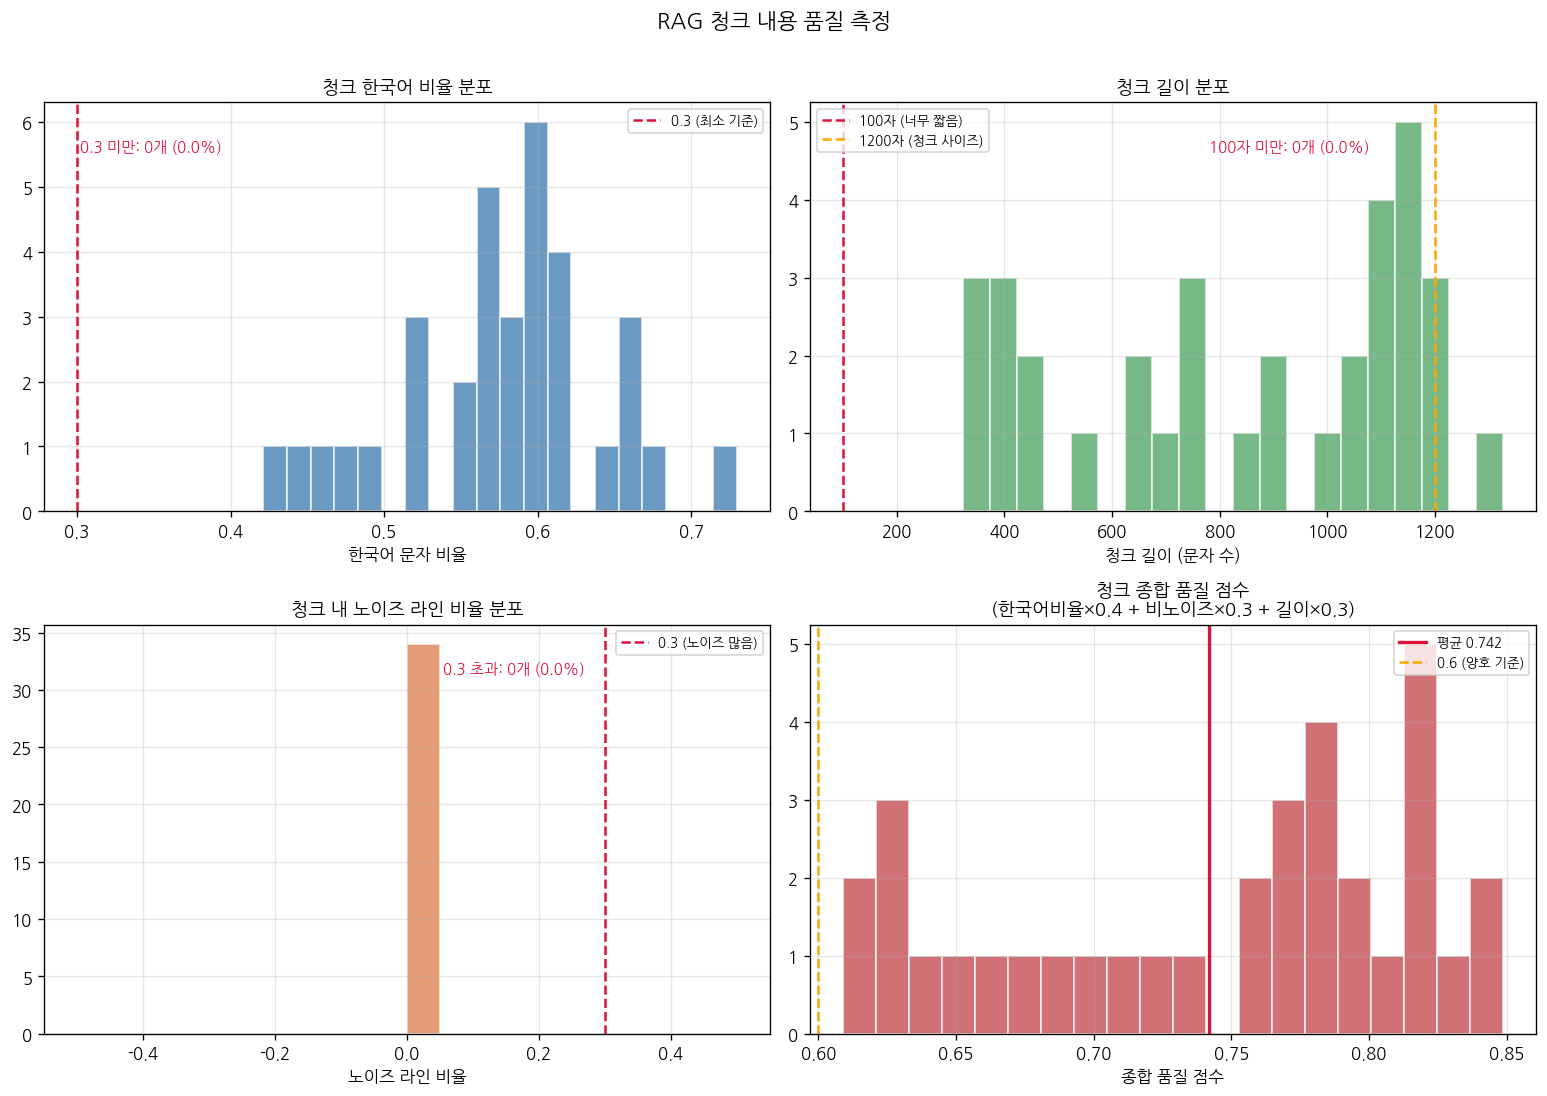

품질 양호 (≥0.6): 34/51 (66.7%)


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# 한국어 비율
ax = axes[0][0]
ax.hist(df_chunks.korean_ratio, bins=20, color='steelblue', alpha=0.8, edgecolor='white')
ax.axvline(0.3, color='crimson', linestyle='--', linewidth=1.5, label='0.3 (최소 기준)')
ax.set_xlabel('한국어 문자 비율', fontsize=10)
ax.set_title('청크 한국어 비율 분포', fontsize=11)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
low_korean = (df_chunks.korean_ratio < 0.3).sum()
ax.text(0.05, 0.88, f'0.3 미만: {low_korean}개 ({low_korean/len(df_chunks):.1%})',
        transform=ax.transAxes, fontsize=9, color='crimson')

# 청크 길이
ax = axes[0][1]
ax.hist(df_chunks.length, bins=20, color='#55A868', alpha=0.8, edgecolor='white')
ax.axvline(100,  color='crimson', linestyle='--', linewidth=1.5, label='100자 (너무 짧음)')
ax.axvline(1200, color='orange',  linestyle='--', linewidth=1.5, label='1200자 (청크 사이즈)')
ax.set_xlabel('청크 길이 (문자 수)', fontsize=10)
ax.set_title('청크 길이 분포', fontsize=11)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
short = (df_chunks.length < 100).sum()
ax.text(0.55, 0.88, f'100자 미만: {short}개 ({short/len(df_chunks):.1%})',
        transform=ax.transAxes, fontsize=9, color='crimson')

# 노이즈 라인 비율
ax = axes[1][0]
ax.hist(df_chunks.noise_line_ratio, bins=20, color='#DD8452', alpha=0.8, edgecolor='white')
ax.axvline(0.3, color='crimson', linestyle='--', linewidth=1.5, label='0.3 (노이즈 많음)')
ax.set_xlabel('노이즈 라인 비율', fontsize=10)
ax.set_title('청크 내 노이즈 라인 비율 분포', fontsize=11)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
noisy = (df_chunks.noise_line_ratio > 0.3).sum()
ax.text(0.55, 0.88, f'0.3 초과: {noisy}개 ({noisy/len(df_chunks):.1%})',
        transform=ax.transAxes, fontsize=9, color='crimson')

# 품질 종합 스코어 (0~1, 높을수록 좋음)
ax = axes[1][1]
df_chunks['quality_score'] = (
    df_chunks.korean_ratio.clip(0, 1) * 0.4 +
    (1 - df_chunks.noise_line_ratio).clip(0, 1) * 0.3 +
    (df_chunks.length / 1200).clip(0, 1) * 0.3
)
ax.hist(df_chunks.quality_score, bins=20, color='#C44E52', alpha=0.8, edgecolor='white')
ax.axvline(df_chunks.quality_score.mean(), color='crimson', linestyle='-',
           linewidth=2, label=f'평균 {df_chunks.quality_score.mean():.3f}')
ax.axvline(0.6, color='orange', linestyle='--', linewidth=1.5, label='0.6 (양호 기준)')
ax.set_xlabel('종합 품질 점수', fontsize=10)
ax.set_title('청크 종합 품질 점수\n(한국어비율×0.4 + 비노이즈×0.3 + 길이×0.3)', fontsize=11)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.suptitle('RAG 청크 내용 품질 측정', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('data/fig_rag_chunk_quality.png', bbox_inches='tight')
plt.show()

good = (df_chunks.quality_score >= 0.6).sum()
print(f'품질 양호 (≥0.6): {good}/{len(df_chunks)} ({good/len(df_chunks):.1%})')

In [16]:
# 품질 하위 5개 청크 내용 출력 — 실제로 어떤 내용인지 확인
print('품질 하위 5개 청크 (실제 내용 확인):')
print('=' * 70)
worst = df_chunks.nsmallest(5, 'quality_score')
for _, row in worst.iterrows():
    print(f'chunk_id: {row.chunk_id}')
    print(f'quality={row.quality_score:.3f} | 한국어={row.korean_ratio:.2f} | 노이즈={row.noise_line_ratio:.2f} | 길이={row.length}')
    print(f'내용 (앞 200자): {str(row.content)[:200]}')
    print('-' * 70)

품질 하위 5개 청크 (실제 내용 확인):
chunk_id: nan
quality=0.609 | 한국어=0.53 | 노이즈=0.00 | 길이=393.0
내용 (앞 200자): nan
----------------------------------------------------------------------
chunk_id: seoul_energy_p0014_c01
quality=0.616 | 한국어=0.57 | 노이즈=0.00 | 길이=347.0
내용 (앞 200자): 인사이트 및 결론

1.  **공간적 고착화(Spatial Fixation)와 다핵화된 도시 기능의 완성**: 6년간 코로나19 팬데믹 (2020년-2022년)이라는 전례 없는 충격에도 25개 자치구의 군집 이동은 단 한 건도 발생하지 않았다. 서울시의 공간 구조가 '생활 중심(주거)'과 '활동 중심(상업·업무)'으로 완전히 분화되어 그 위계가 확고하게 고
----------------------------------------------------------------------
chunk_id: seoul_energy_p0001_c01
quality=0.622 | 한국어=0.59 | 노이즈=0.00 | 길이=338.0
내용 (앞 200자): **[서술 텍스트]**
제목: 다차원 지표 기반의 서울시 자치구별 에너지 소비 패턴 및 정주 환경 분석입니다.
소제목: K-means 군집화 기반 에너지 소비 패턴 분석입니다.
설명문: 이 보고서의 분석 기간은 2019년부터 2024년까지이며, 작성자는 안주강입니다.
설명문: 작성일은 2026년 4월 22일입니다.
본문: 분석 대상은 서울시 25개 자치구의
----------------------------------------------------------------------
chunk_id: nan
quality=0.625 | 한국어=0.61 | 노이즈=0.00 | 길이=324.0
내용 (앞 200자): nan
-------------------

---
## 4. match_count 민감도 분석

> **검증 목적**: 현재 match_count=5가 최적인가?  
> k가 커질수록 더 많은 청크가 들어오지만, 관련 없는 청크가 섞일 위험도 커진다.  
> 각 k에서 상위 청크의 평균 similarity가 얼마나 떨어지는지 확인한다.

[DEBUG] RAG Query: 강남구 에너지 소비 특성
[DEBUG] RPC Returned Row Count : 3 (threshold=0.7)
[DEBUG] RAG Query: 서울시 군집 분석 결과
[DEBUG] RPC Returned Row Count : 3 (threshold=0.7)
[DEBUG] RAG Query: 동작구 가정용 전력 추세
[DEBUG] RPC Returned Row Count : 3 (threshold=0.7)
[DEBUG] RAG Query: 자치구 비교 에너지 구조
[DEBUG] RPC Returned Row Count : 3 (threshold=0.7)
[DEBUG] RAG Query: 서울 주거 밀집 지역 특성
[DEBUG] RPC Returned Row Count : 3 (threshold=0.7)
[DEBUG] RAG Query: 강남구 에너지 소비 특성
[DEBUG] RPC Returned Row Count : 5 (threshold=0.7)
[DEBUG] RAG Query: 서울시 군집 분석 결과
[DEBUG] RPC Returned Row Count : 5 (threshold=0.7)
[DEBUG] RAG Query: 동작구 가정용 전력 추세
[DEBUG] RPC Returned Row Count : 5 (threshold=0.7)
[DEBUG] RAG Query: 자치구 비교 에너지 구조
[DEBUG] RPC Returned Row Count : 5 (threshold=0.7)
[DEBUG] RAG Query: 서울 주거 밀집 지역 특성
[DEBUG] RPC Returned Row Count : 5 (threshold=0.7)
[DEBUG] RAG Query: 강남구 에너지 소비 특성
[DEBUG] RPC Returned Row Count : 7 (threshold=0.7)
[DEBUG] RAG Query: 서울시 군집 분석 결과
[DEBUG] RPC Returned Row Count : 7 (threshol

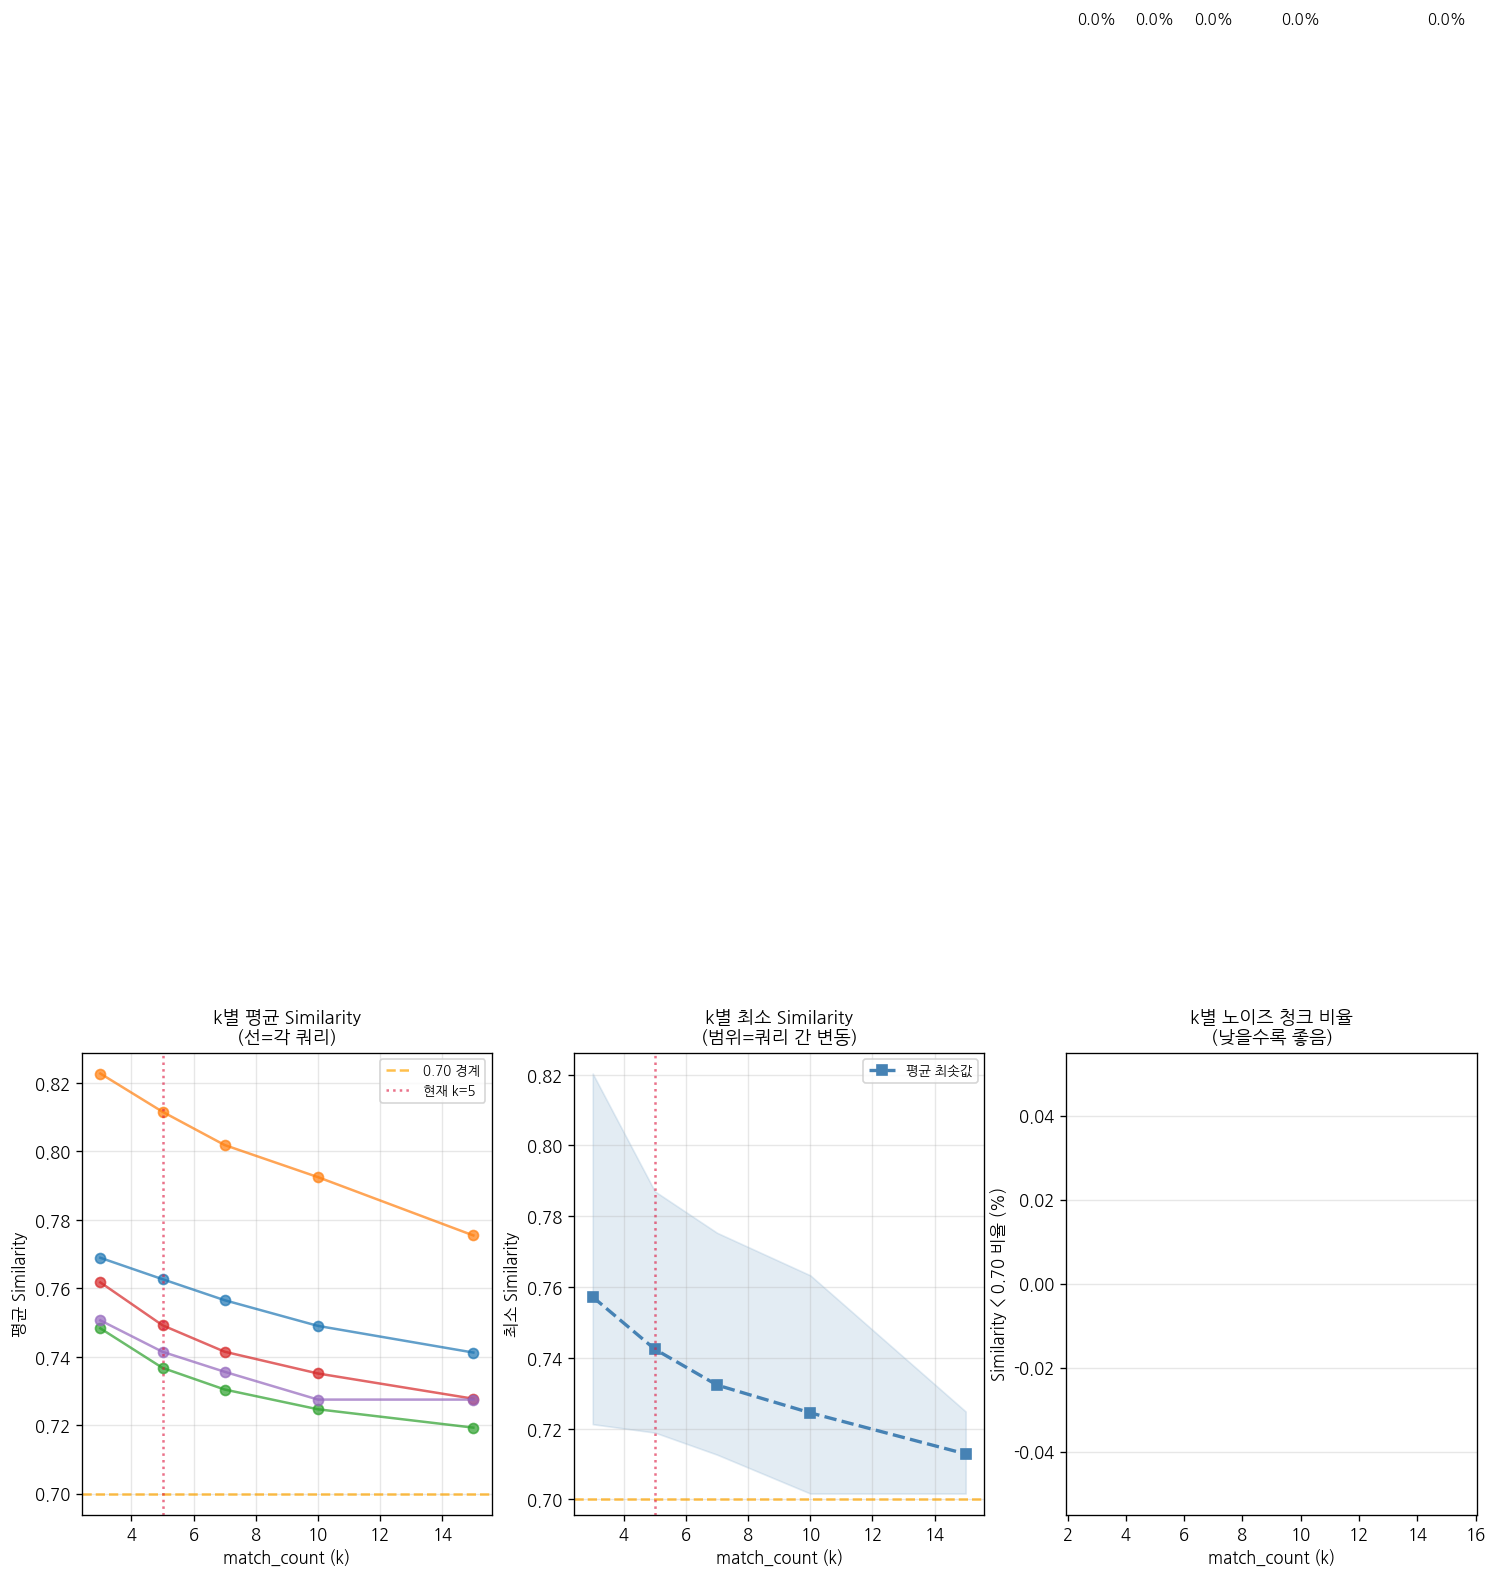

k별 요약 (전체 쿼리 평균):
 k  mean_sim  min_sim  below_07_pct
 3    0.7704   0.7572           0.0
 5    0.7603   0.7424           0.0
 7    0.7531   0.7323           0.0
10    0.7457   0.7245           0.0
15    0.7382   0.7129           0.0


In [18]:
# 대표 쿼리 5개에 대해 k=3, 5, 7, 10, 15 비교
PROBE_QUERIES = [
    '강남구 에너지 소비 특성',
    '서울시 군집 분석 결과',
    '동작구 가정용 전력 추세',
    '자치구 비교 에너지 구조',
    '서울 주거 밀집 지역 특성',
]
K_VALS = [3, 5, 7, 10, 15]

k_results = []
for k in K_VALS:
    for q in PROBE_QUERIES:
        docs = search_rag_documents(q, match_count=k)
        # ── Fix 1: None similarity 제거 후 float 변환 ──
        sims = [float(d['similarity']) for d in docs if d.get('similarity') is not None]
        k_results.append({
            'k':            k,
            'query':        q,
            'mean_sim':     float(np.mean(sims)) if sims else 0.0,
            'min_sim':      float(np.min(sims))  if sims else 0.0,
            'top1_sim':     sims[0]              if sims else 0.0,
            'below_07_pct': sum(1 for s in sims if s < 0.70) / max(len(sims), 1),
        })

df_k = pd.DataFrame(k_results)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 평균 similarity
ax = axes[0]
for q in PROBE_QUERIES:
    sub = df_k[df_k['query'] == q].sort_values('k')
    ax.plot(sub.k, sub.mean_sim, 'o-', alpha=0.7, linewidth=1.5)
ax.axhline(0.70, color='orange', linestyle='--', alpha=0.7, label='0.70 경계')
ax.axvline(5, color='crimson', linestyle=':', alpha=0.6, label='현재 k=5')
ax.set_xlabel('match_count (k)', fontsize=10)
ax.set_ylabel('평균 Similarity', fontsize=10)
ax.set_title('k별 평균 Similarity\n(선=각 쿼리)', fontsize=11)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# 최솟값 similarity
ax = axes[1]
agg = df_k.groupby('k').agg({'mean_sim': 'mean', 'min_sim': 'mean', 'below_07_pct': 'mean'}).reset_index()
# ── Fix 2: .values로 인덱스 불일치 방지 ──
min_by_k = df_k.groupby('k')['min_sim'].min().reindex(agg.k).values
max_by_k = df_k.groupby('k')['min_sim'].max().reindex(agg.k).values
ax.plot(agg.k, agg.min_sim, 's--', color='steelblue', linewidth=2, label='평균 최솟값')
ax.fill_between(agg.k.values, min_by_k, max_by_k, alpha=0.15, color='steelblue')
ax.axhline(0.70, color='orange', linestyle='--', alpha=0.7)
ax.axvline(5, color='crimson', linestyle=':', alpha=0.6)
ax.set_xlabel('match_count (k)', fontsize=10)
ax.set_ylabel('최소 Similarity', fontsize=10)
ax.set_title('k별 최소 Similarity\n(범위=쿼리 간 변동)', fontsize=11)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# 0.70 미만 비율
ax = axes[2]
bar_colors = ['crimson' if kv == 5 else 'steelblue' for kv in agg.k]
bars = ax.bar(agg.k, agg.below_07_pct * 100, color=bar_colors, alpha=0.8, edgecolor='white')
for bar, val in zip(bars, agg.below_07_pct):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{val * 100:.1f}%', ha='center', fontsize=9)
ax.set_xlabel('match_count (k)', fontsize=10)
ax.set_ylabel('Similarity < 0.70 비율 (%)', fontsize=10)
ax.set_title('k별 노이즈 청크 비율\n(낮을수록 좋음)', fontsize=11)
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('data/fig_rag_k_sensitivity.png', bbox_inches='tight')
plt.show()

print('k별 요약 (전체 쿼리 평균):')
print(agg.round(4).to_string(index=False))


---
## 5. 질문 유형별 검색 정밀도 육안 검토

> 자동화 지표만으로는 안 보이는 것들이 있다.  
> 쿼리별 Top-3 청크가 실제로 연관 있는지 직접 확인한다.

In [19]:
# 범주별 대표 쿼리 1개씩 Top-3 청크 출력
INSPECT_QUERIES = {
    '자치구 특성':  '강남구 에너지 소비 특성',
    '군집 분석':   '서울시 에너지 소비 군집 특성',
    '트렌드 변화':  '인구 감소와 에너지 소비 관계',
    '비교 분석':   '강남구 동작구 비교',
}

for category, query in INSPECT_QUERIES.items():
    docs = seararch_rag_documents(query, match_count=3)
    print(f'\n[{category}] 쿼리: "{query}"')
    print('=' * 65)
    for i, doc in enumerate(docs, 1):
        sim   = doc.get('similarity', 0)
        sec   = doc.get('section', '')
        text  = doc.get('content', '')[:150].replace('\n', ' ')
        badge = '✅' if sim >= 0.85 else ('⚠️' if sim >= 0.70 else '❌')
        print(f'  #{i} {badge} sim={sim:.4f} | 섹션: {sec}')
        print(f'     {text}...')
        print()

NameError: name 'seararch_rag_documents' is not defined

---
## 6. RAGAS 정량 평가

> **RAGAS**: RAG 시스템 평가 특화 프레임워크  
> `pip install ragas` 필요
>
> 측정 지표:
> | 지표 | 의미 |
> |------|------|
> | **Faithfulness** | LLM 답변이 검색된 청크에 근거하는가 (환각 측정) |
> | **Answer Relevancy** | 답변이 질문과 실제로 관련있는가 |
> | **Context Precision** | 검색된 청크가 답에 실제로 필요한가 |
> | **Context Recall** | 답에 필요한 정보가 청크에 다 있는가 |

In [20]:
# 테스트 Q&A 셋 — 직접 작성한 정답 기준
# ground_truth: 보고서 또는 DB에서 확인한 사실 기반으로 작성
QA_TESTSET = [
    {
        'question':     '강남구의 에너지 소비 구조적 특성은 무엇인가?',
        'ground_truth': '강남구는 서비스업과 산업용 전력 비율이 합계 85% 이상으로 서울시에서 가장 높은 활동 중심형 자치구이다. 가정용 비율은 약 10~12%로 매우 낮다.',
    },
    {
        'question':     '동작구는 어떤 에너지 소비 패턴을 가지는가?',
        'ground_truth': '동작구는 가정용 전력 비율이 약 27~30%로 높아 주거 중심 자치구로 분류된다. 서비스업과 산업용 합계는 강남구보다 낮다.',
    },
    {
        'question':     '서울시 25개 자치구의 군집 분석 결과 몇 개 군집으로 나뉘는가?',
        'ground_truth': '서울시 25개 자치구는 K=6 군집으로 분류된다. 도심 핵심형, 광역 거점형, 주거 밀집형 등으로 구분된다.',
    },
    {
        'question':     '중구와 도봉구의 가정용 전력 비율 차이는 얼마인가?',
        'ground_truth': '중구는 가정용 전력 비율이 약 4.7~5.6%로 서울시 최저 수준이며, 도봉구는 30% 이상으로 두 자치구의 차이는 25%p 이상이다.',
    },
    {
        'question':     '강동구가 군집을 이동한 이유는 무엇인가?',
        'ground_truth': '강동구는 2020년에 가구 수 11% 급증과 코로나19 팬데믹이 맞물리며 군집 4에서 군집 5로 이동했다.',
    },
    {
        'question':     '서울시에서 가스 보급률이 높은 군집의 특성은?',
        'ground_truth': '가스 보급률이 높은 군집은 주거 밀집형으로 강북구, 도봉구, 노원구 등이 속하며 가정용 전력 비율도 30% 이상이다.',
    },
    {
        'question':     '서비스업 전력 비율이 가장 높은 자치구는 어디인가?',
        'ground_truth': '강남구, 서초구, 중구 등이 서비스업 전력 비율이 높으며 광역 상업 거점 또는 도심 핵심 군집에 속한다.',
    },
    {
        'question':     '서울시 에너지 소비 분석의 주요 목적은 무엇인가?',
        'ground_truth': '자치구별 생활 중심성과 활동 중심성의 차이를 에너지 데이터로 분석하여 맞춤형 도시 에너지 정책 수립에 시사점을 제공한다.',
    },
    {
        'question':     '분석에 사용된 데이터 기간과 출처는?',
        'ground_truth': '2019~2024년 6개년 데이터로, 한국가스공사, 통계청, 서울열린데이터광장을 출처로 한다.',
    },
    {
        'question':     '군집 분석에 사용된 피처는 몇 가지이며 어떤 항목인가?',
        'ground_truth': '7개 지표를 사용했다. 상주인구, 총가구수, 가스보급률, 가정용 비율, 공공용 비율, 서비스업 비율, 산업용 비율이다.',
    },
]

print(f'테스트 Q&A 셋: {len(QA_TESTSET)}개')

테스트 Q&A 셋: 10개


In [21]:
try:
    from ragas import evaluate
    from ragas.metrics import faithfulness, answer_relevancy, context_precision, context_recall
    from datasets import Dataset
    RAGAS_AVAILABLE = True
    print('RAGAS 사용 가능')
except ImportError:
    RAGAS_AVAILABLE = False
    print('RAGAS 미설치 → pip install ragas datasets')
    print('RAGAS 없이 수동 precision 측정으로 대체한다.')

RAGAS 사용 가능


In [22]:
# ── RAGAS 실행 ───────────────────────────────────────────────
if RAGAS_AVAILABLE:
    import os
    from langchain_google_genai import ChatGoogleGenerativeAI, GoogleGenerativeAIEmbeddings
    from ragas.llms import LangchainLLMWrapper
    from ragas.embeddings import LangchainEmbeddingsWrapper
    from services.answer_service import answer_question
    from services.db_service import search_rag_documents  

    # ── Gemini 주입 ──────────────────────────────────────────
    ragas_llm = LangchainLLMWrapper(
        ChatGoogleGenerativeAI(
            model="gemini-2.5-flash",
            google_api_key=os.environ["GOOGLE_API_KEY"]
        )
    )
    ragas_emb = LangchainEmbeddingsWrapper(
        GoogleGenerativeAIEmbeddings(
            model="models/gemini-embedding-001",
            google_api_key=os.environ["GOOGLE_API_KEY"]
        )
    )

    faithfulness.llm            = ragas_llm
    answer_relevancy.llm        = ragas_llm
    answer_relevancy.embeddings = ragas_emb
    context_precision.llm       = ragas_llm
    context_recall.llm          = ragas_llm

    # ── 데이터 수집 ──────────────────────────────────────────
    ragas_data = {'question': [], 'answer': [], 'contexts': [], 'ground_truth': []}

    for item in QA_TESTSET:
        q  = item['question']
        gt = item['ground_truth']

        result   = answer_question(q)
        answer   = result.get('summary', '')
        docs     = search_rag_documents(q, match_count=5)  # 오타 수정
        contexts = [d.get('content', '') for d in docs]

        ragas_data['question'].append(q)
        ragas_data['answer'].append(answer)
        ragas_data['contexts'].append(contexts)
        ragas_data['ground_truth'].append(gt)
        print(f'  처리: {q[:40]}...')

    # ── 평가 ─────────────────────────────────────────────────
    dataset = Dataset.from_dict(ragas_data)
    scores  = evaluate(
        dataset,
        metrics=[faithfulness, answer_relevancy, context_precision, context_recall]
    )
    print('\nRAGAS 평가 결과:')
    print(scores)

[DEBUG] RAG Query: 강남구 전체 전력사용량 변화 추세 에너지 소비 특성
[DEBUG] RPC Returned Row Count : 5 (threshold=0.7)
[DEBUG] RAG Query: 강남구의 에너지 소비 구조적 특성은 무엇인가?
[DEBUG] RPC Returned Row Count : 5 (threshold=0.7)
  처리: 강남구의 에너지 소비 구조적 특성은 무엇인가?...
[DEBUG] RAG Query: 동작구 전체 전력사용량 변화 추세 에너지 소비 특성
[DEBUG] RPC Returned Row Count : 5 (threshold=0.7)
[DEBUG] RAG Query: 동작구는 어떤 에너지 소비 패턴을 가지는가?
[DEBUG] RPC Returned Row Count : 5 (threshold=0.7)
  처리: 동작구는 어떤 에너지 소비 패턴을 가지는가?...
[DEBUG] RAG Query: 서울시 에너지 소비 현황 군집 특성 추세
[DEBUG] RPC Returned Row Count : 5 (threshold=0.7)
[DEBUG] RAG Query: 서울시 25개 자치구의 군집 분석 결과 몇 개 군집으로 나뉘는가?
[DEBUG] RPC Returned Row Count : 5 (threshold=0.7)
  처리: 서울시 25개 자치구의 군집 분석 결과 몇 개 군집으로 나뉘는가?...
[DEBUG] RAG Query: 도봉구 가정용 전력사용량 변화 추세 에너지 소비 특성
[DEBUG] RPC Returned Row Count : 5 (threshold=0.7)
[DEBUG] RAG Query: 중구와 도봉구의 가정용 전력 비율 차이는 얼마인가?
[DEBUG] RPC Returned Row Count : 1 (threshold=0.7)
  처리: 중구와 도봉구의 가정용 전력 비율 차이는 얼마인가?...


Exception in thread Thread-11 (_readerthread):
Traceback (most recent call last):
  File "c:\Users\vacke\anaconda3\Lib\threading.py", line 1043, in _bootstrap_inner
    self.run()
    ~~~~~~~~^^
  File "c:\Users\vacke\anaconda3\Lib\site-packages\ipykernel\ipkernel.py", line 766, in run_closure
    _threading_Thread_run(self)
    ~~~~~~~~~~~~~~~~~~~~~^^^^^^
  File "c:\Users\vacke\anaconda3\Lib\threading.py", line 994, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\vacke\anaconda3\Lib\subprocess.py", line 1615, in _readerthread
    buffer.append(fh.read())
                  ~~~~~~~^^
  File "<frozen codecs>", line 325, in decode
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xba in position 24: invalid start byte
  File "c:\Users\vacke\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 262, in _count_physical_cores
    cpu_info = cpu_info.stdout.splitlines()
               ^^^^^^^^^^^^^^^^

[DEBUG] RAG Query: 강동구 Cluster 주거 밀집형 1 특징 에너지 소비 해석
[DEBUG] RPC Returned Row Count : 3 (threshold=0.7)
[DEBUG] RAG Query: 강동구가 군집을 이동한 이유는 무엇인가?
[DEBUG] RPC Returned Row Count : 0 (threshold=0.7)
  처리: 강동구가 군집을 이동한 이유는 무엇인가?...
[DEBUG] RAG Query: 서울시 에너지 소비 현황 군집 특성 추세
[DEBUG] RPC Returned Row Count : 5 (threshold=0.7)
[DEBUG] RAG Query: 서울시에서 가스 보급률이 높은 군집의 특성은?
[DEBUG] RPC Returned Row Count : 5 (threshold=0.7)
  처리: 서울시에서 가스 보급률이 높은 군집의 특성은?...
[DEBUG] RAG Query: 서비스업 전력 비율이 가장 높은 자치구는 어디인가?
[DEBUG] RPC Returned Row Count : 3 (threshold=0.7)
[DEBUG] RAG Query: 서비스업 전력 비율이 가장 높은 자치구는 어디인가?
[DEBUG] RPC Returned Row Count : 3 (threshold=0.7)
  처리: 서비스업 전력 비율이 가장 높은 자치구는 어디인가?...
[DEBUG] RAG Query: 서울시 에너지 소비 현황 군집 특성 추세
[DEBUG] RPC Returned Row Count : 5 (threshold=0.7)
[DEBUG] RAG Query: 서울시 에너지 소비 분석의 주요 목적은 무엇인가?
[DEBUG] RPC Returned Row Count : 5 (threshold=0.7)
  처리: 서울시 에너지 소비 분석의 주요 목적은 무엇인가?...
[DEBUG] RAG Query: 분석에 사용된 데이터 기간과 출처는?
[DEBUG] RPC Returned Row Count : 1 (thresho

Evaluating:   0%|          | 0/40 [00:00<?, ?it/s]

LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.



RAGAS 평가 결과:
{'faithfulness': 0.4617, 'answer_relevancy': 0.7607, 'context_precision': 0.5667, 'context_recall': 0.4500}


In [25]:
# ── RAGAS 미설치 시: 수동 Context Precision 측정 ──────────────
# 각 질문에 대해 Top-5 청크가 ground_truth의 핵심 키워드를 포함하는지 확인

def extract_keywords(text: str) -> set:
    """텍스트에서 의미있는 한국어 명사구 추출 (간단 버전)"""
    # 자치구명, 수치, 핵심 용어 추출
    patterns = [
        r'[가-힣]{2,}구',          # 자치구명
        r'\d+[.\d]*%',             # 비율
        r'[가-힣]{2,}용',           # XX용 (가정용, 산업용 등)
        r'군집\s*\d+',             # 군집번호
        r'[가-힣]{3,}(?=\s|$)',   # 3자 이상 한국어 단어
    ]
    keywords = set()
    for p in patterns:
        keywords.update(re.findall(p, text))
    return keywords

manual_results = []
for item in QA_TESTSET:
    q  = item['question']
    gt = item['ground_truth']
    gt_kw = extract_keywords(gt)

    docs = search_rag_documents(q, match_count=5)
    all_context = ' '.join(d.get('content','') for d in docs)
    ctx_kw = extract_keywords(all_context)

    hit = len(gt_kw & ctx_kw)
    total = max(len(gt_kw), 1)
    recall = hit / total

    manual_results.append({
        'question':          q[:40] + '...',
        'gt_keywords':       len(gt_kw),
        'matched_keywords':  hit,
        'keyword_recall':    recall,
        'avg_similarity':    np.mean([d['similarity'] for d in docs]),
    })

df_manual = pd.DataFrame(manual_results)
print('수동 Keyword Recall 측정 결과:')
print(df_manual.to_string(index=False))
print(f'\n평균 Keyword Recall: {df_manual.keyword_recall.mean():.3f}')
print(f'평균 Similarity:     {df_manual.avg_similarity.mean():.4f}')

[DEBUG] RAG Query: 강남구의 에너지 소비 구조적 특성은 무엇인가?
[DEBUG] RPC Returned Row Count : 5 (threshold=0.7)
[DEBUG] RAG Query: 동작구는 어떤 에너지 소비 패턴을 가지는가?
[DEBUG] RPC Returned Row Count : 5 (threshold=0.7)
[DEBUG] RAG Query: 서울시 25개 자치구의 군집 분석 결과 몇 개 군집으로 나뉘는가?
[DEBUG] RPC Returned Row Count : 5 (threshold=0.7)
[DEBUG] RAG Query: 중구와 도봉구의 가정용 전력 비율 차이는 얼마인가?
[DEBUG] RPC Returned Row Count : 1 (threshold=0.7)
[DEBUG] RAG Query: 강동구가 군집을 이동한 이유는 무엇인가?
[DEBUG] RPC Returned Row Count : 0 (threshold=0.7)
[DEBUG] RAG Query: 서울시에서 가스 보급률이 높은 군집의 특성은?
[DEBUG] RPC Returned Row Count : 5 (threshold=0.7)
[DEBUG] RAG Query: 서비스업 전력 비율이 가장 높은 자치구는 어디인가?
[DEBUG] RPC Returned Row Count : 3 (threshold=0.7)
[DEBUG] RAG Query: 서울시 에너지 소비 분석의 주요 목적은 무엇인가?
[DEBUG] RPC Returned Row Count : 5 (threshold=0.7)
[DEBUG] RAG Query: 분석에 사용된 데이터 기간과 출처는?
[DEBUG] RPC Returned Row Count : 1 (threshold=0.7)
[DEBUG] RAG Query: 군집 분석에 사용된 피처는 몇 가지이며 어떤 항목인가?
[DEBUG] RPC Returned Row Count : 1 (threshold=0.7)
수동 Keyword Recall 측정 결과:


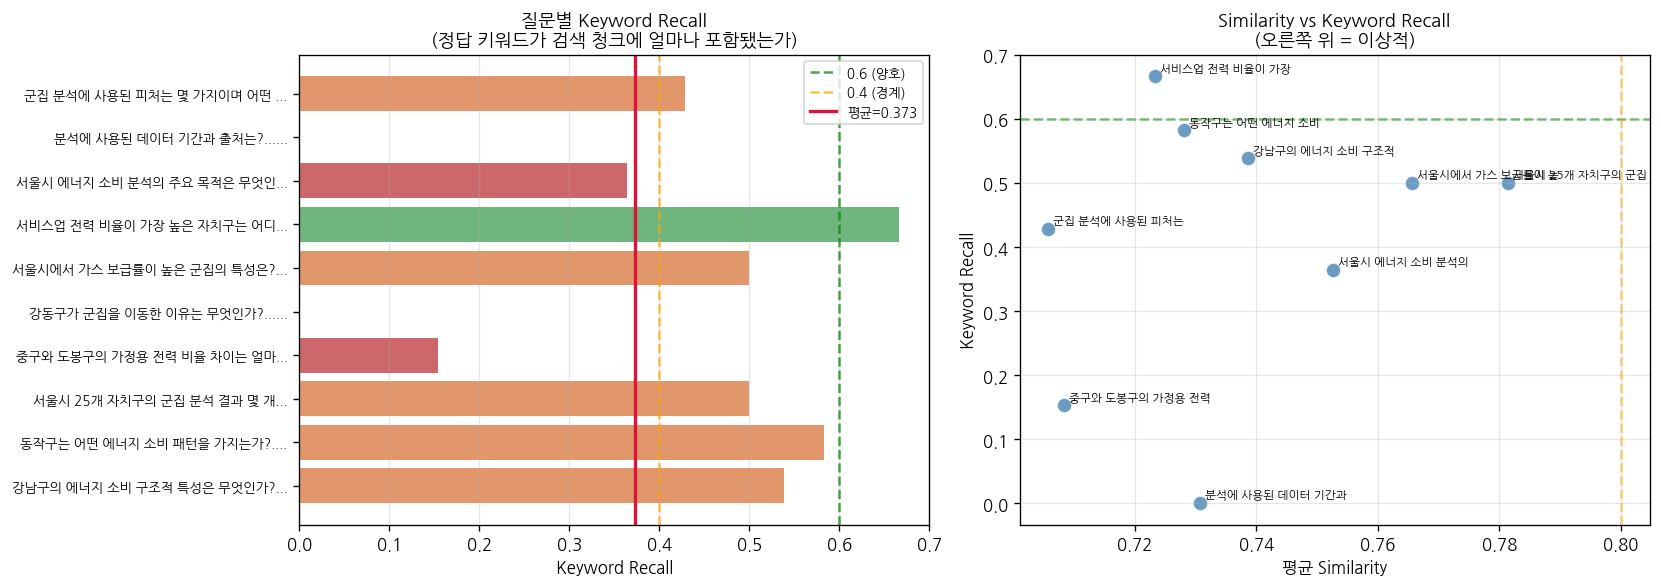

In [26]:
# 수동 측정 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Keyword Recall by question
ax = axes[0]
colors_bar = ['#55A868' if v >= 0.6 else '#DD8452' if v >= 0.4 else '#C44E52'
              for v in df_manual.keyword_recall]
bars = ax.barh(range(len(df_manual)), df_manual.keyword_recall, color=colors_bar, alpha=0.85)
ax.axvline(0.6, color='green',  linestyle='--', alpha=0.7, label='0.6 (양호)')
ax.axvline(0.4, color='orange', linestyle='--', alpha=0.7, label='0.4 (경계)')
ax.axvline(df_manual.keyword_recall.mean(), color='crimson', linestyle='-',
           linewidth=2, label=f'평균={df_manual.keyword_recall.mean():.3f}')
ax.set_yticks(range(len(df_manual)))
ax.set_yticklabels([q[:25]+'...' for q in df_manual.question], fontsize=8)
ax.set_xlabel('Keyword Recall', fontsize=10)
ax.set_title('질문별 Keyword Recall\n(정답 키워드가 검색 청크에 얼마나 포함됐는가)', fontsize=11)
ax.legend(fontsize=8)
ax.grid(alpha=0.3, axis='x')

# similarity vs recall scatter
ax2 = axes[1]
ax2.scatter(df_manual.avg_similarity, df_manual.keyword_recall,
            s=80, color='steelblue', alpha=0.8, edgecolors='white')
for _, row in df_manual.iterrows():
    ax2.annotate(row['question'][:15], (row['avg_similarity'], row['keyword_recall']),
                 fontsize=7, ha='left', xytext=(3, 3), textcoords='offset points')
ax2.axhline(0.6, color='green',  linestyle='--', alpha=0.5)
ax2.axvline(0.80, color='orange', linestyle='--', alpha=0.5)
ax2.set_xlabel('평균 Similarity', fontsize=10)
ax2.set_ylabel('Keyword Recall', fontsize=10)
ax2.set_title('Similarity vs Keyword Recall\n(오른쪽 위 = 이상적)', fontsize=11)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('data/fig_rag_manual_eval.png', bbox_inches='tight')
plt.show()

---
## 7. 종합 요약 및 개선 방향

In [27]:
# 자동 요약 출력
mean_sim       = df_rag.similarity.mean()
low_sim_pct    = (df_rag.similarity < 0.70).mean()
good_chunk_pct = (df_chunks.quality_score >= 0.6).mean()
k5_noise       = df_k[df_k.k==5]['below_07_pct'].mean()
mean_recall    = df_manual.keyword_recall.mean()

print('=' * 65)
print('  RAG 청크 품질 검증 종합 결과')
print('=' * 65)
print()
print(f'[1] Similarity Score')
print(f'    전체 평균: {mean_sim:.4f}')
print(f'    0.70 미만(노이즈 의심): {low_sim_pct:.1%}')
grade_sim = '✅ 양호' if mean_sim >= 0.80 else ('⚠️ 보통' if mean_sim >= 0.70 else '❌ 개선 필요')
print(f'    판정: {grade_sim}')
print()
print(f'[2] 청크 내용 품질')
print(f'    품질 양호(≥0.6) 비율: {good_chunk_pct:.1%}')
grade_chunk = '✅ 양호' if good_chunk_pct >= 0.7 else ('⚠️ 보통' if good_chunk_pct >= 0.5 else '❌ 개선 필요')
print(f'    판정: {grade_chunk}')
print()
print(f'[3] match_count=5 노이즈 비율: {k5_noise:.1%}')
grade_k = '✅ 양호' if k5_noise <= 0.1 else ('⚠️ 보통' if k5_noise <= 0.2 else '❌ 개선 필요')
print(f'    판정: {grade_k}')
print()
print(f'[4] Keyword Recall (수동 평가)')
print(f'    평균: {mean_recall:.3f}')
grade_recall = '✅ 양호' if mean_recall >= 0.6 else ('⚠️ 보통' if mean_recall >= 0.4 else '❌ 개선 필요')
print(f'    판정: {grade_recall}')
print()
print('=' * 65)
print('  한계점 및 연구 방향')
print('=' * 65)
print()
print('1. 벡터 유사도 기반 검색은 자치구 간 관계 구조를 반영하지 못한다.')
print('   → GraphRAG: 자치구를 노드, 군집 소속·인접 관계를 엣지로 표현')
print('   → 강남구 쿼리 시 서초구·송파구(동일 군집)가 자동으로 연관 검색되는 구조')
print()
print('2. 청크 경계가 문단 단위로 고정되어 있어')
print('   한 청크 안에 여러 자치구가 섞이는 문제가 발생했다.')
print('   → Small-to-Big Retrieval: 작은 청크로 검색, 큰 청크로 컨텍스트 제공')
print()
print('3. Keyword Recall이 낮은 질문들은 정답 키워드가 청크에 없는 경우다.')
print('   → 청크 커버리지 분석: 보고서의 어떤 섹션이 검색에서 누락되는지 확인 필요')
print()
print('4. RAGAS 정량 평가를 통해 Faithfulness(환각) 측정이 필요하다.')
print('   → pip install ragas 후 섹션 6의 RAGAS 셀 실행')

  RAG 청크 품질 검증 종합 결과

[1] Similarity Score
    전체 평균: 0.7363
    0.70 미만(노이즈 의심): 0.0%
    판정: ⚠️ 보통

[2] 청크 내용 품질
    품질 양호(≥0.6) 비율: 66.7%
    판정: ⚠️ 보통

[3] match_count=5 노이즈 비율: 0.0%
    판정: ✅ 양호

[4] Keyword Recall (수동 평가)
    평균: 0.373
    판정: ❌ 개선 필요

  한계점 및 연구 방향

1. 벡터 유사도 기반 검색은 자치구 간 관계 구조를 반영하지 못한다.
   → GraphRAG: 자치구를 노드, 군집 소속·인접 관계를 엣지로 표현
   → 강남구 쿼리 시 서초구·송파구(동일 군집)가 자동으로 연관 검색되는 구조

2. 청크 경계가 문단 단위로 고정되어 있어
   한 청크 안에 여러 자치구가 섞이는 문제가 발생했다.
   → Small-to-Big Retrieval: 작은 청크로 검색, 큰 청크로 컨텍스트 제공

3. Keyword Recall이 낮은 질문들은 정답 키워드가 청크에 없는 경우다.
   → 청크 커버리지 분석: 보고서의 어떤 섹션이 검색에서 누락되는지 확인 필요

4. RAGAS 정량 평가를 통해 Faithfulness(환각) 측정이 필요하다.
   → pip install ragas 후 섹션 6의 RAGAS 셀 실행
